<h2>Predicting the Trend of Imported Cars in Thailand<h2>


<h2>Data Preparation<h2>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Set Thai font support
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['TH Sarabun New', 'Tahoma', 'Arial']

# Load the raw CSV to inspect it
with open('2024-2025car.csv', 'r', encoding='utf-8') as file:
    print("Raw CSV content (first 5 lines):")
    for i, line in enumerate(file):
        if i < 5:
            print(line.strip())
        else:
            break

# Load the data with error handling
try:
    df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8')
except pd.errors.ParserError as e:
    print(f"ParserError occurred: {e}")
    df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8', on_bad_lines='skip')

# Filter for "Sedan (Not more than 7 Pass)" only
df_cars = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)'].copy()  # Use .copy() to avoid view issues

# Filter for "Sedan (Not more than 7 Pass)" only
df_cars = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)'].copy()  # Use .copy() to avoid view issues

# Print column names and first few rows to verify structure
print("\nColumn names:", df_cars.columns.tolist())
print("\nFirst 5 rows of filtered data:")
print(df_cars.head())

# Ensure 'Amount' is numeric, replacing invalid values with 0, using .loc
df_cars.loc[:, 'Amount'] = pd.to_numeric(df_cars['Amount'], errors='coerce').fillna(0)

# Filter data for each year
df_2565 = df_cars[df_cars['Year'] == 2565]
df_2566 = df_cars[df_cars['Year'] == 2566]
df_2567 = df_cars[df_cars['Year'] == 2567]

Raw CSV content (first 5 lines):
Year,Month,Types of Cars,Brands,Car Model,Amount
2565,December,Sedan (Not more than 7 Pass),AUDI,A1 SB 35 TFSI S line,2
2565,December,Sedan (Not more than 7 Pass),AUDI,A4 AV 45 TFSI q S line BE,2
2565,December,Sedan (Not more than 7 Pass),AUDI,A5 CP 40 TFSI S line,10
2565,December,Sedan (Not more than 7 Pass),AUDI,A5 CP 45 TFSI q S line BE,4

Column names: ['Year', 'Month', 'Types of Cars', 'Brands', 'Car Model', 'Amount']

First 5 rows of filtered data:
   Year     Month                 Types of Cars Brands  \
0  2565  December  Sedan (Not more than 7 Pass)   AUDI   
1  2565  December  Sedan (Not more than 7 Pass)   AUDI   
2  2565  December  Sedan (Not more than 7 Pass)   AUDI   
3  2565  December  Sedan (Not more than 7 Pass)   AUDI   
4  2565  December  Sedan (Not more than 7 Pass)   AUDI   

                   Car Model  Amount  
0       A1 SB 35 TFSI S line     2.0  
1  A4 AV 45 TFSI q S line BE     2.0  
2       A5 CP 40 TFSI S line    10.0  
3  

<h2>Data Visual<h2>

In [9]:
# Function to create pie chart for a given year
def plot_pie_chart(df, year):
    # Group data by brand and sum the quantities
    brand_summary = df.groupby('Brands')['Amount'].sum().reset_index()
    
    # Sort and get top 10 brands with positive values
    top_10_brands = brand_summary[brand_summary['Amount'] > 0].nlargest(10, 'Amount')
    
    # Check if we have valid data
    if top_10_brands.empty:
        #ไม่มีข้อมูลที่ถูกต้องสำหรับการสร้างแผนภูมิสำหรับปี {year}
        print(f"\nThere is no accurate data available for creating a Pie Chart for Year {year}")
        print("Brand summary (all values):")
        print(brand_summary)
    else:
        #อันดับยี่ห้อที่มีการจดทะเบียนสูงสุดสำหรับปี {year}
        print(f"\n10 Brands with the Highest Number of Registrations for Year {year}:")
        print(top_10_brands)
        
        # Prepare data for the pie chart
        labels = top_10_brands['Brands']
        sizes = top_10_brands['Amount']
        explode = [0.1] * len(labels)
        
        # Create the pie chart with adjusted font sizes
        plt.figure(figsize=(10, 8))
        plt.pie(sizes, 
                labels=labels, 
                explode=explode, 
                autopct=lambda pct: f'{pct:.1f}%\n' if pct > 10 else '', 
                startangle=90, 
                colors=plt.cm.Pastel1.colors,
                textprops={'fontsize': 10, 'weight': 'bold'},  # Reduced label font size
                pctdistance=0.85)  # Adjust percentage text position
        
        #การกระจายของยอดจดทะเบียนรถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน 10 อันดับยี่ห้อ ปี {year}
        plt.title(f'The Pie Chart of Sedan (Not more than 7 Pass) Registrations for the Top 10 brands for Year {year}', 
                  fontsize=14,  # Reduced title font size
                  weight='bold', 
                  pad=20)
        
        plt.axis('equal')
        plt.tight_layout()
        plt.show()


10 Brands with the Highest Number of Registrations for Year 2565:
        Brands    Amount
53      TOYOTA  185074.0
22       ISUZU  112507.0
19       HONDA   88863.0
38  MITSUBISHI   39662.0
31       MAZDA   35911.0
36          MG   29526.0
16        FORD   27884.0
40      NISSAN   21412.0
50      SUZUKI   19093.0
5          BMW   13572.0


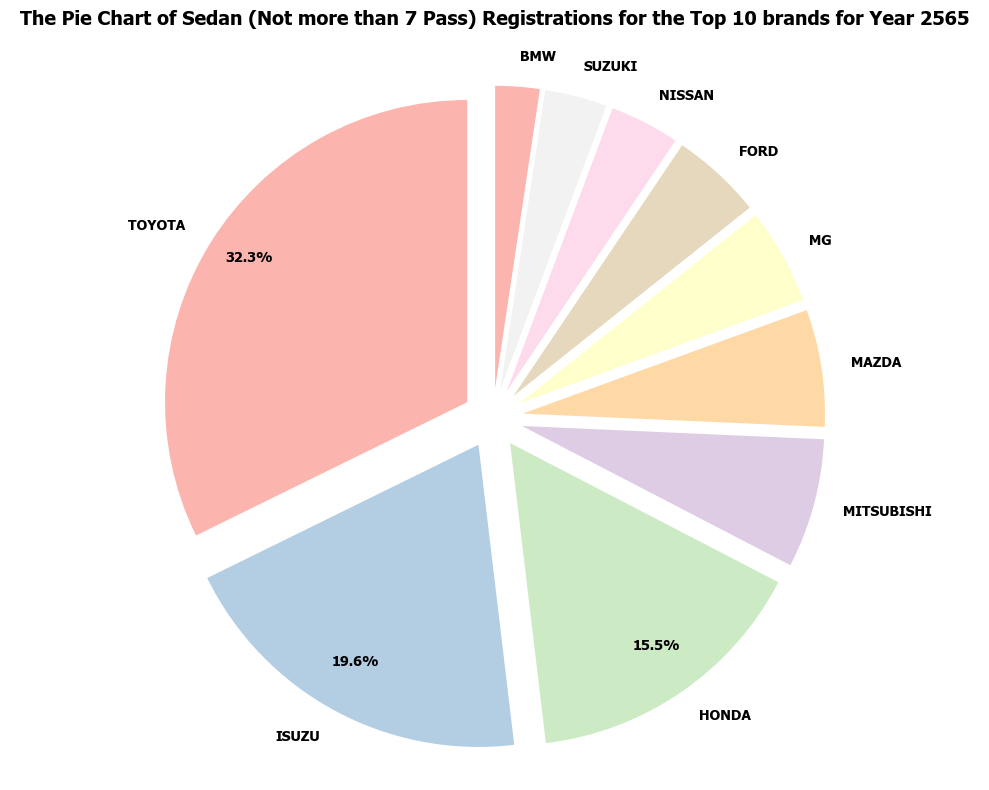

In [11]:
# Plot for 2565
plot_pie_chart(df_2565, 2565)




10 Brands with the Highest Number of Registrations for Year 2566:
        Brands    Amount
65      TOYOTA  198837.0
25       ISUZU   92469.0
22       HONDA   91678.0
17        FORD   37569.0
46  MITSUBISHI   31064.0
44          MG   28546.0
6          BYD   26657.0
39       MAZDA   22578.0
49      NISSAN   16242.0
5          BMW   14185.0


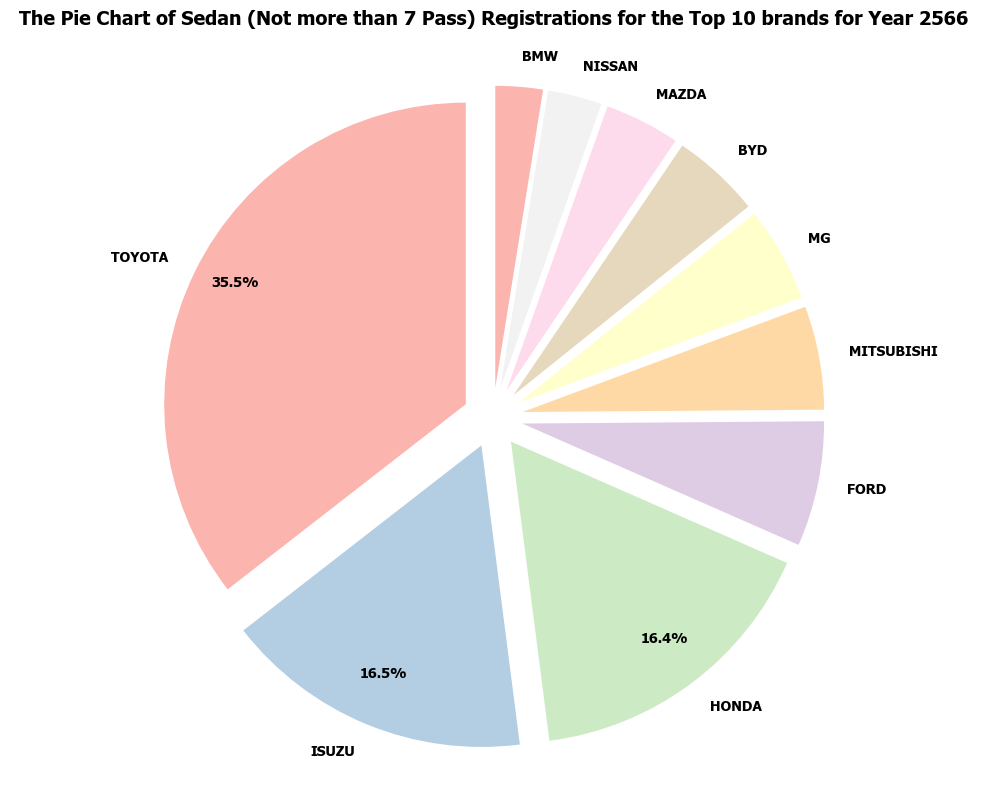

In [12]:
# Plot for 2566
plot_pie_chart(df_2566, 2566)


10 Brands with the Highest Number of Registrations for Year 2567:
        Brands    Amount
61      TOYOTA  223029.0
24       HONDA  128772.0
27       ISUZU   75090.0
20        FORD   36465.0
9          BYD   32189.0
45  MITSUBISHI   29882.0
43          MG   25405.0
8          BMW   17045.0
40       MAZDA   16163.0
48      NISSAN   14287.0


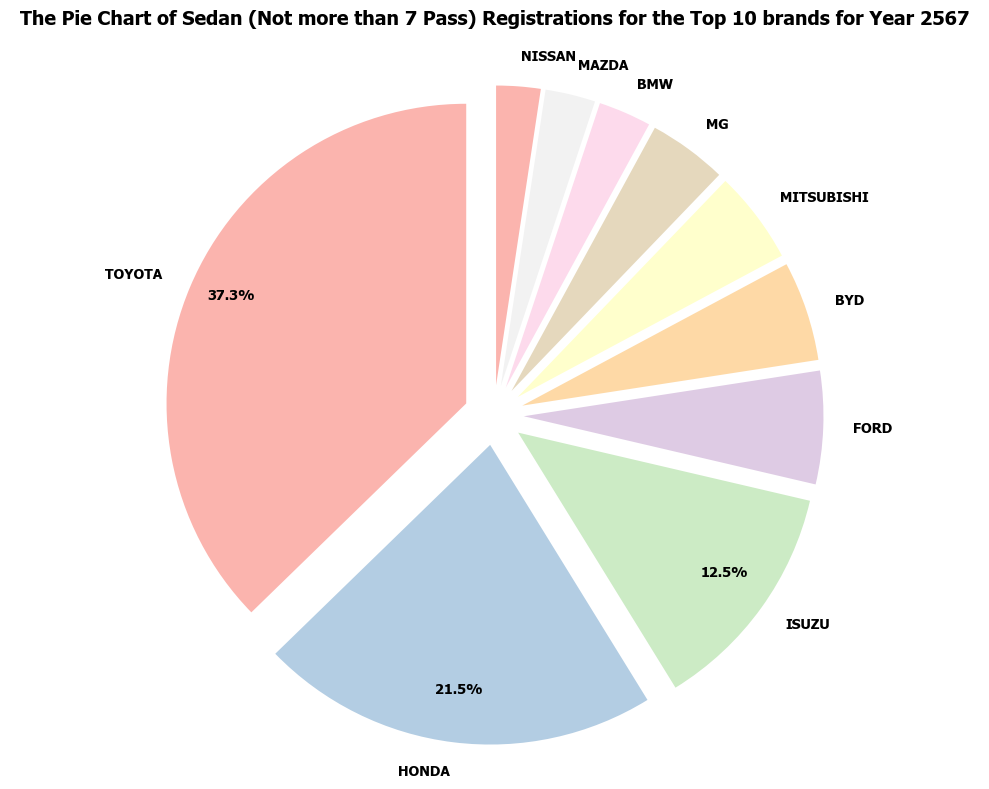

In [14]:
# Plot for 2565
plot_pie_chart(df_2567, 2567)

<h2>Plot_bar_chart_brands<h2>

In [18]:
def plot_bar_chart_brands(df, year):
    brand_summary = df.groupby('Brands')['Amount'].sum().reset_index()
    top_10_brands = brand_summary[brand_summary['Amount'] > 0].nlargest(10, 'Amount')
    
    if top_10_brands.empty:
        #ไม่มีข้อมูลที่ถูกต้องสำหรับการสร้างแผนภูมิแท่ง (Brands) สำหรับปี {year}
        print(f"\nThere is no accurate data available for creating a Bar Chart (Brands) for {year}")
        print("Brand summary (all values):")
        print(brand_summary)
    else:
        print(f"\n10 Brands with the Highest Number of Registrations for {year} Bar):")
        print(top_10_brands)
        
        plt.figure(figsize=(12, 6))
        plt.bar(top_10_brands['Brands'], top_10_brands['Amount'], color=plt.cm.Pastel1.colors[:len(top_10_brands)])
        plt.xlabel('Brands', fontsize=12)
        plt.ylabel('The Number of Registrations', fontsize=12) #จำนวนการจดทะเบียน
        plt.title(f'The Number of Sedan (Not more than 7 Pass) Registrations for the Top 10 brands for {year}', #ยอดจดทะเบียนรถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน 10 อันดับยี่ห้อ ปี
                  fontsize=14, 
                  weight='bold', 
                  pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.tight_layout()
        plt.show()

# Function to create bar chart for models
def plot_bar_chart_models(df, year):
    model_summary = df.groupby('Car Model')['Amount'].sum().reset_index()
    top_10_models = model_summary[model_summary['Amount'] > 0].nlargest(10, 'Amount')
    
    if top_10_models.empty:
        #ไม่มีข้อมูลที่ถูกต้องสำหรับการสร้างแผนภูมิแท่ง (Car Model) สำหรับปี {year}
        print(f"\nThere is no accurate data available for creating a Bar Chart (Car Model) for {year}")
        print("Model summary (all values):")
        print(model_summary)
    else:
        #อันดับรุ่นที่มีการจดทะเบียนสูงสุดสำหรับปี {year}
        print(f"\n10 Car Models with the Highest Number of Registrations for {year} (Bar):")
        print(top_10_models)
        
        plt.figure(figsize=(12, 6))
        plt.bar(top_10_models['Car Model'], top_10_models['Amount'], color=plt.cm.Pastel2.colors[:len(top_10_models)])
        plt.xlabel('Car Model', fontsize=12)
        plt.ylabel('The Number of Registrations', fontsize=12) #จำนวนการจดทะเบียน
        plt.title(f'The Number of Sedan (Not more than 7 Pass) Registrations for the Top 10 Car Models for {year}', #ยอดจดทะเบียนรถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน 10 อันดับรุ่น ปี
                  fontsize=14, 
                  weight='bold', 
                  pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=8)  # Smaller font for model names due to length
        plt.tight_layout()
        plt.show()



10 Brands with the Highest Number of Registrations for 2565 Bar):
        Brands    Amount
53      TOYOTA  185074.0
22       ISUZU  112507.0
19       HONDA   88863.0
38  MITSUBISHI   39662.0
31       MAZDA   35911.0
36          MG   29526.0
16        FORD   27884.0
40      NISSAN   21412.0
50      SUZUKI   19093.0
5          BMW   13572.0


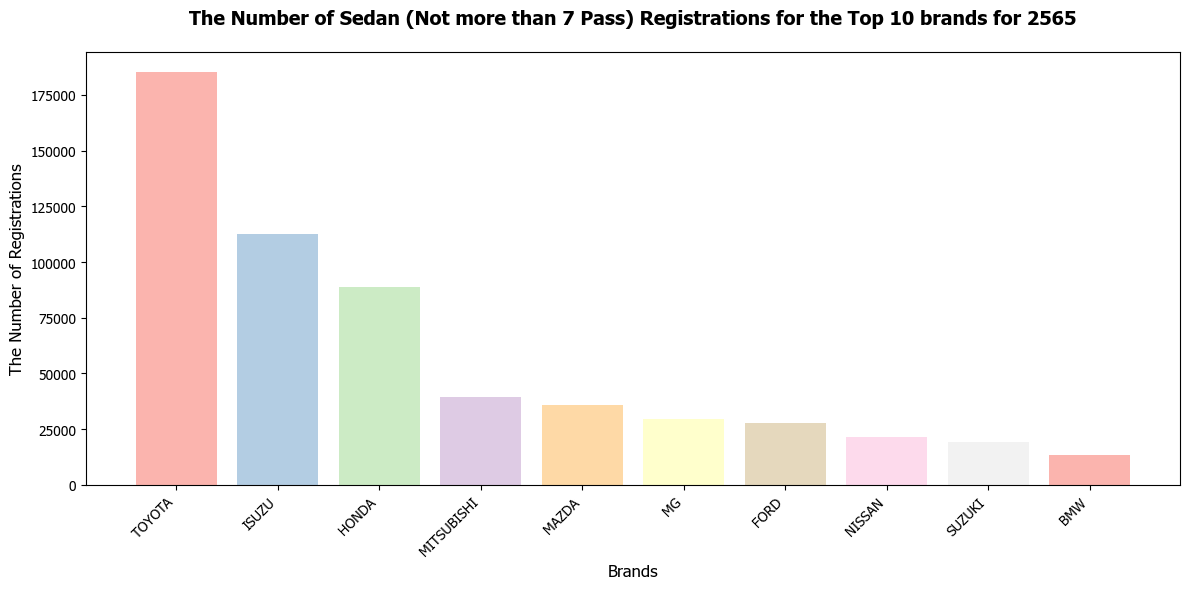

In [20]:
# Plot for 2565
plot_bar_chart_brands(df_2565, 2565)




10 Car Models with the Highest Number of Registrations for 2565 (Bar):
           Car Model   Amount
385            D-MAX  93108.0
563       HILUX REVO  50119.0
1101           YARIS  28472.0
473         FORTUNER  27130.0
1102      YARIS ATIV  26403.0
308             CITY  23873.0
309   CITY HATCHBACK  22348.0
344    COROLLA CROSS  21443.0
722             MU-X  19373.0
842           RANGER  19134.0


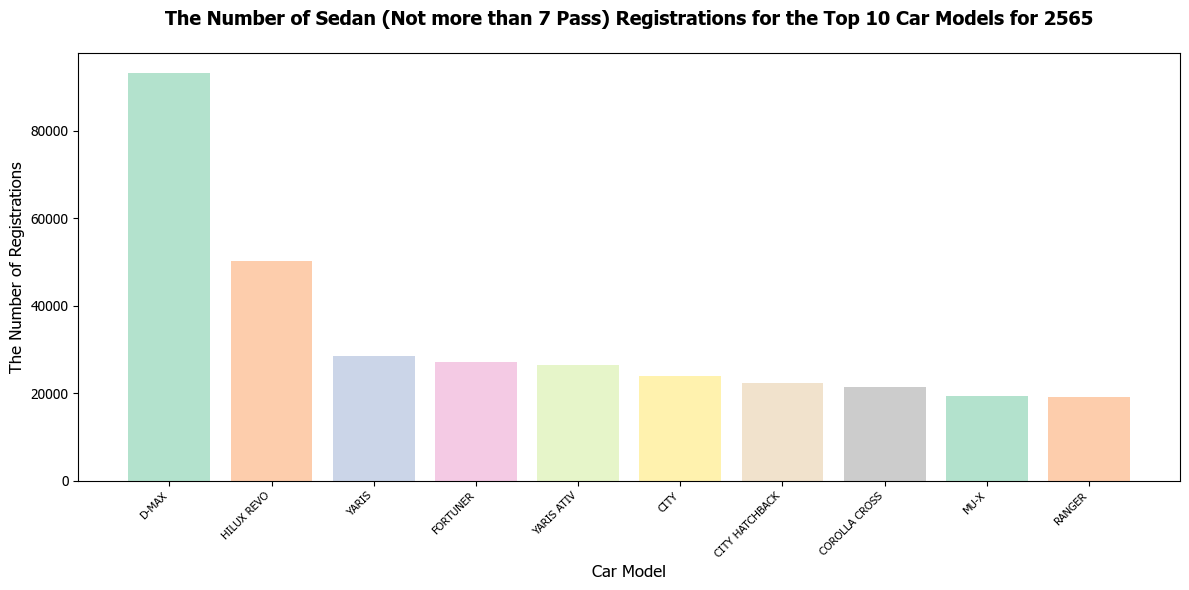

In [21]:
plot_bar_chart_models(df_2565, 2565)


10 Brands with the Highest Number of Registrations for 2566 Bar):
        Brands    Amount
61      TOYOTA  223029.0
24       HONDA  128772.0
27       ISUZU   75090.0
20        FORD   36465.0
9          BYD   32189.0
45  MITSUBISHI   29882.0
43          MG   25405.0
8          BMW   17045.0
40       MAZDA   16163.0
48      NISSAN   14287.0


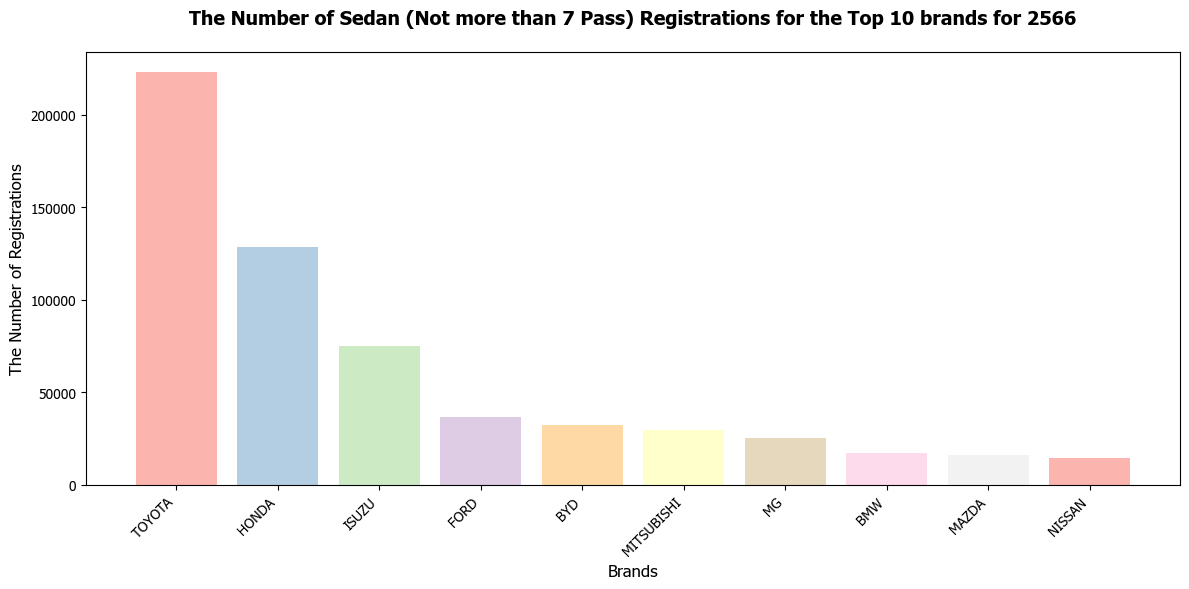

In [23]:

plot_bar_chart_brands(df_2567, 2566)



10 Car Models with the Highest Number of Registrations for 2566 (Bar):
           Car Model   Amount
379            D-MAX  69579.0
1094      YARIS ATIV  54838.0
571       HILUX REVO  45962.0
476         FORTUNER  26181.0
309   CITY HATCHBACK  23170.0
728             MU-X  22878.0
572             HR-V  22249.0
308             CITY  20929.0
340    COROLLA CROSS  20259.0
845           RANGER  20184.0


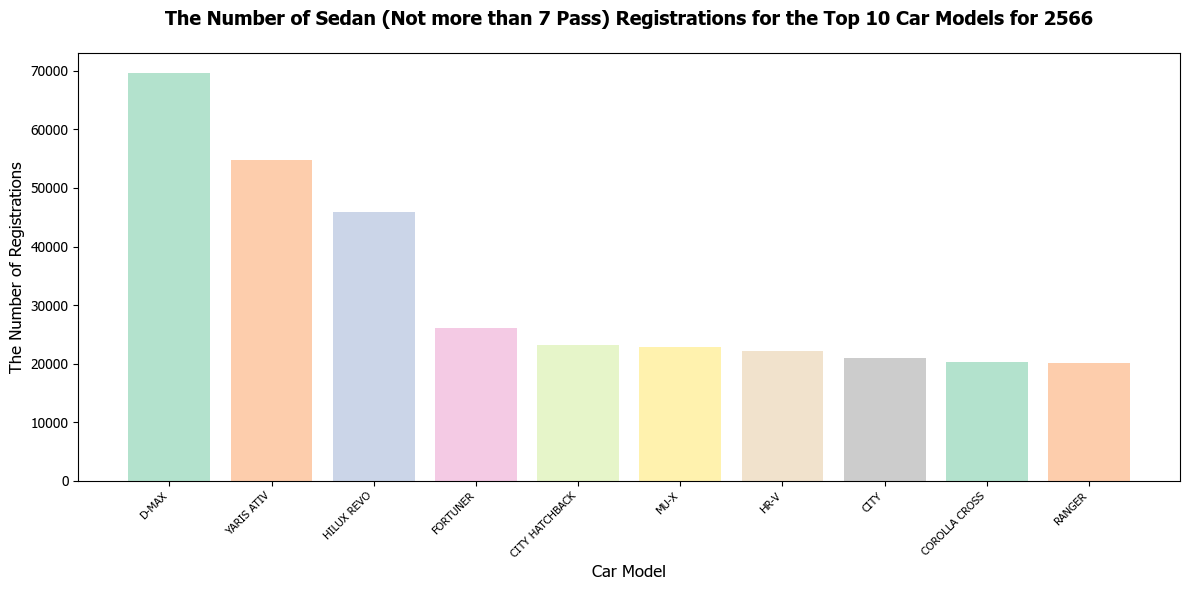

In [25]:

plot_bar_chart_models(df_2566, 2566)


10 Car Models with the Highest Number of Registrations for 2567 (Bar):
          Car Model   Amount
921      YARIS ATIV  68986.0
322           D-MAX  56116.0
485      HILUX REVO  43112.0
486            HR-V  36362.0
266            CITY  28924.0
922     YARIS CROSS  25671.0
290   COROLLA CROSS  24562.0
401        FORTUNER  22356.0
267  CITY HATCHBACK  21406.0
627            MU-X  18972.0


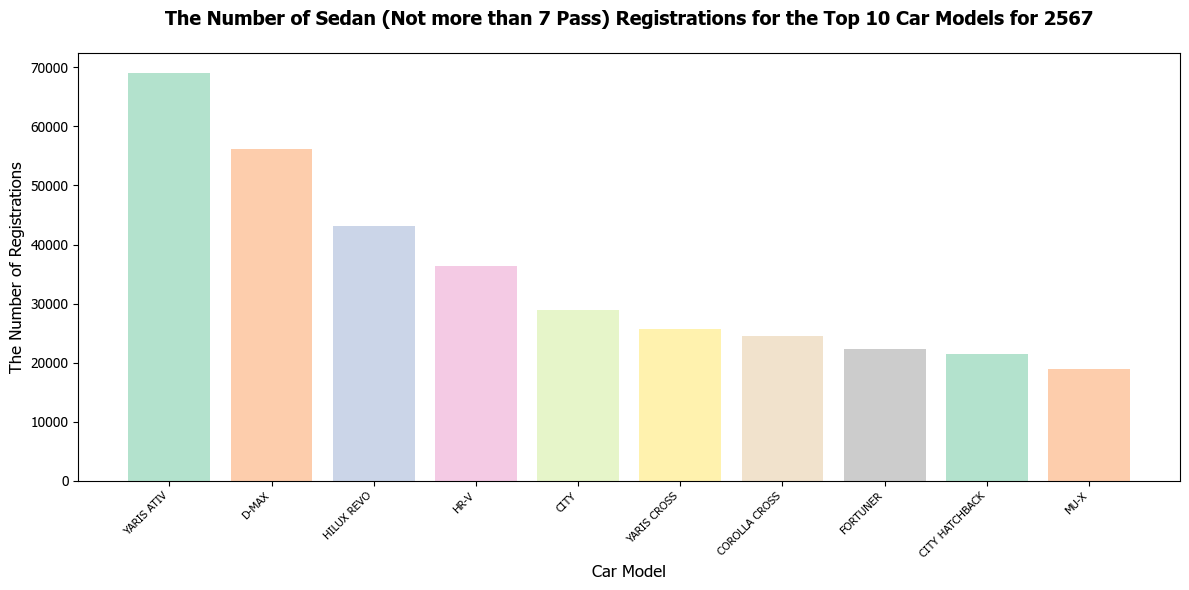

In [27]:

plot_bar_chart_models(df_2567, 2567)

<h2>Growth Rated from linear regression<h2>


Predictions for TOYOTA in 2568:
        Month   Amount  predicted_2568
0     January  20773.0         2091.79
1    February  19991.0         2013.04
2       March  20709.0         2085.34
3       April  15501.0         1560.91
4         May  17175.0         1729.48
5        June  17107.0         1722.63
6        July  14349.0         1444.91
7      August  16623.0         1673.89
8   September  14954.0         1505.83
9     October  14921.0         1502.51
10   November  15230.0         1533.62
11   December  11504.0         1158.42

Predictions for ISUZU in 2568:
        Month   Amount  predicted_2568
0     January  11032.0          556.14
1    February  10611.0          534.92
2       March  10348.0          521.66
3       April   7933.0          399.92
4         May   9247.0          466.16
5        June   7768.0          391.60
6        July   6011.0          303.03
7      August   6851.0          345.37
8   September   5703.0          287.50
9     October   4964.0          250.24

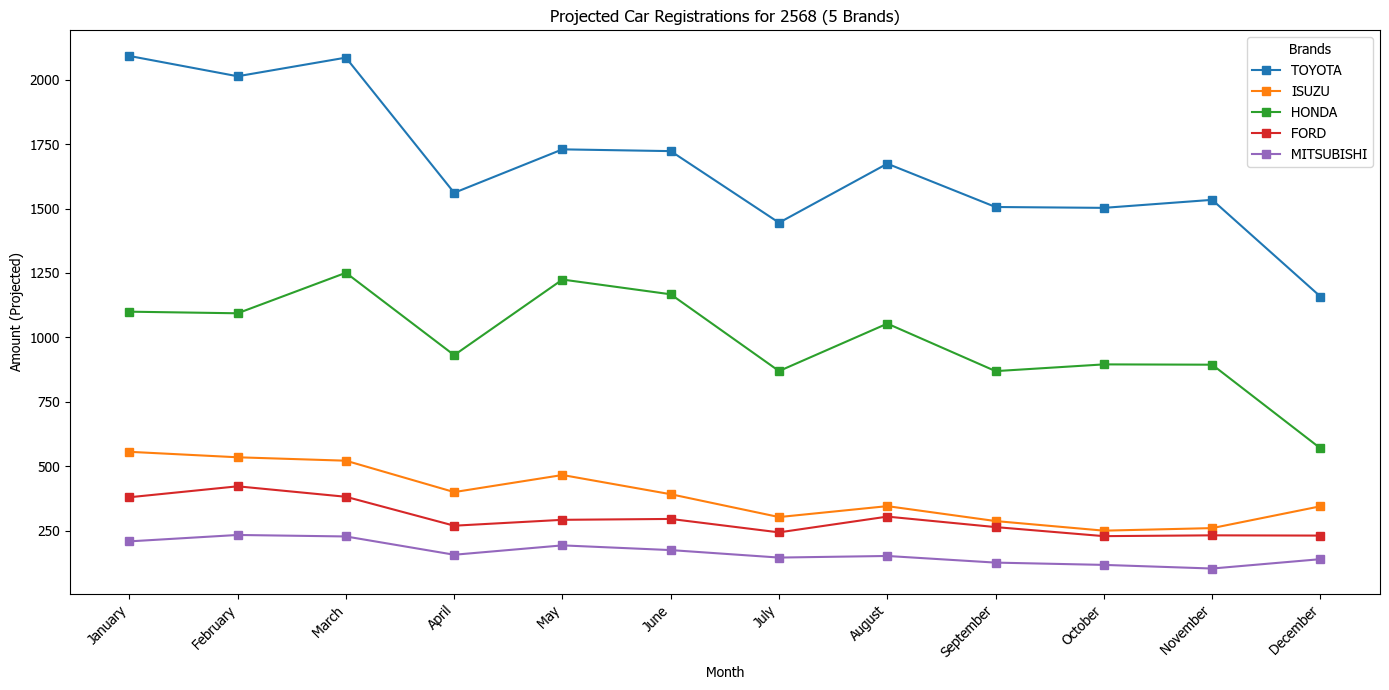

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Set Thai font support
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['TH Sarabun New', 'Tahoma', 'Arial']

# Load data
df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8', on_bad_lines='skip')

# Filter for "รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน" and ensure 'Amount' is numeric
df_cars = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)'].copy()
df_cars['Amount'] = pd.to_numeric(df_cars['Amount'], errors='coerce').fillna(0)

# Filter data for 2565, 2566, and 2567
df_2565 = df_cars[df_cars['Year'] == 2565]
df_2566 = df_cars[df_cars['Year'] == 2566]
df_2567 = df_cars[df_cars['Year'] == 2567]

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Summarize by brand and month
brand_month_2565 = df_2565.groupby(['Brands', 'Month'])['Amount'].sum().reset_index()
brand_month_2566 = df_2566.groupby(['Brands', 'Month'])['Amount'].sum().reset_index()
brand_month_2567 = df_2567.groupby(['Brands', 'Month'])['Amount'].sum().reset_index()

# Merge data for regression (2565, 2566, 2567)
brand_month = pd.concat([brand_month_2565.assign(year=2565), 
                         brand_month_2566.assign(year=2566), 
                         brand_month_2567.assign(year=2567)])

# Get top 5 brands by total 2566 registrations
top_brands = brand_month_2566.groupby('Brands')['Amount'].sum().nlargest(5).index
brand_month = brand_month[brand_month['Brands'].isin(top_brands)]

# Convert month to numeric for regression (not used directly here, but kept for potential future use)
month_to_num = {month: i+1 for i, month in enumerate(month_order)}
brand_month['month_num'] = brand_month['Month'].map(month_to_num)

# Prepare data for regression and prediction
predictions_2568 = []
for brand in top_brands:
    brand_data = brand_month[brand_month['Brands'] == brand]
    
    # X: year, y: Amount
    X = brand_data[['year']].values
    y = brand_data['Amount'].values
    
    # Train Linear Regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict total for 2568
    predicted_2568_total = max(model.predict(np.array([[2568]]))[0], 0)  # Ensure non-negative
    
    # Ensure all months from 2566 are included for distribution
    brand_2566 = brand_month_2566[brand_month_2566['Brands'] == brand].copy()
    all_months = pd.DataFrame({'Month': month_order})
    brand_2566 = all_months.merge(brand_2566, on='Month', how='left').fillna({'Amount': 0, 'Brands': brand})
    
    # Distribute total prediction across months based on 2566 proportions
    total_2566 = brand_2566['Amount'].sum()
    if total_2566 == 0:  # If no 2566 data, use uniform distribution or fallback to 2565
        brand_2565 = brand_month_2565[brand_month_2565['Brands'] == brand].copy()
        if not brand_2565.empty:
            brand_2565 = all_months.merge(brand_2565, on='Month', how='left').fillna({'Amount': 0, 'Brands': brand})
            total_2565 = brand_2565['Amount'].sum()
            if total_2565 > 0:
                brand_2566['predicted_2568'] = (brand_2565['Amount'] / total_2565) * predicted_2568_total
            else:
                brand_2566['predicted_2568'] = predicted_2568_total / 12  # Equal distribution
        else:
            brand_2566['predicted_2568'] = predicted_2568_total / 12  # Equal distribution
    else:
        brand_2566['predicted_2568'] = (brand_2566['Amount'] / total_2566) * predicted_2568_total
    
    # Debugging: Check predictions for this brand
    print(f"\nPredictions for {brand} in 2568:")
    print(brand_2566[['Month', 'Amount', 'predicted_2568']].round(2))
    
    predictions_2568.append(brand_2566)

# Combine predictions
brand_month_trend = pd.concat(predictions_2568)
brand_month_trend['Month'] = pd.Categorical(brand_month_trend['Month'], categories=month_order, ordered=True)
brand_month_trend = brand_month_trend.sort_values(['Brands', 'Month'])

# Calculate total predicted registrations per brand for 2568
total_by_brand = brand_month_trend.groupby('Brands')['predicted_2568'].sum().reset_index()
total_by_brand.columns = ['Brands', 'Projected Total_2568']  # ยอดรวมคาดการณ์_2568

# Print results with monthly predictions
print("\nMonthly Car Registration Projections for 2568 (5 Brands):")  # คาดการณ์ยอดจดทะเบียนรถยนต์รายเดือน ปี 2568 (5 Brands)
print(brand_month_trend[['Brands', 'Month', 'predicted_2568']].round(2))

# Print total predictions per brand
print("\nProjected Total for the Year 2568 for 5 Brands:")  # ยอดรวมคาดการณ์ทั้งปี 2568 สำหรับ 5 ยี่ห้อ
print(total_by_brand.round(2))

# Plot Predicted Registrations for 2568
plt.figure(figsize=(14, 7))
for brand in top_brands:
    brand_data = brand_month_trend[brand_month_trend['Brands'] == brand]
    plt.plot(brand_data['Month'], brand_data['predicted_2568'], marker='s', label=brand)

plt.xlabel('Month')
plt.ylabel('Amount (Projected)')  # Projected = คาดการณ์
plt.title('Projected Car Registrations for 2568 (5 Brands)')  # ยอดจดทะเบียนรถยนต์คาดการณ์ ปี 2568 (5 ยี่ห้อ)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Brands')
plt.tight_layout()
plt.show()

Raw CSV content (first 5 lines):
Year,Month,Types of Cars,Brands,Car Model,Amount
2565,December,Sedan (Not more than 7 Pass),AUDI,A1 SB 35 TFSI S line,2
2565,December,Sedan (Not more than 7 Pass),AUDI,A4 AV 45 TFSI q S line BE,2
2565,December,Sedan (Not more than 7 Pass),AUDI,A5 CP 40 TFSI S line,10
2565,December,Sedan (Not more than 7 Pass),AUDI,A5 CP 45 TFSI q S line BE,4

Column names: ['Year', 'Month', 'Types of Cars', 'Brands', 'Car Model', 'Amount']

First 5 rows of filtered data:
   Year     Month                 Types of Cars Brands  \
0  2565  December  Sedan (Not more than 7 Pass)   AUDI   
1  2565  December  Sedan (Not more than 7 Pass)   AUDI   
2  2565  December  Sedan (Not more than 7 Pass)   AUDI   
3  2565  December  Sedan (Not more than 7 Pass)   AUDI   
4  2565  December  Sedan (Not more than 7 Pass)   AUDI   

                   Car Model  Amount  
0       A1 SB 35 TFSI S line     2.0  
1  A4 AV 45 TFSI q S line BE     2.0  
2       A5 CP 40 TFSI S line    10.0  
3  

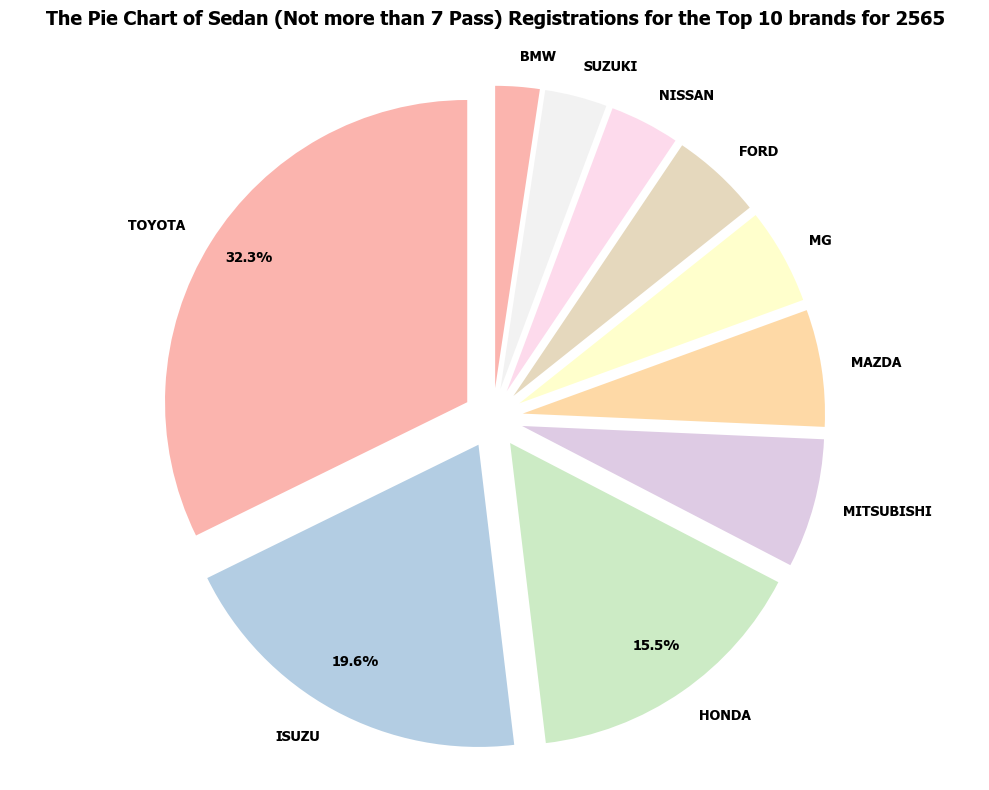


10 Brands with the Highest Number of Registrations for 2566:
        Brands    Amount
65      TOYOTA  198837.0
25       ISUZU   92469.0
22       HONDA   91678.0
17        FORD   37569.0
46  MITSUBISHI   31064.0
44          MG   28546.0
6          BYD   26657.0
39       MAZDA   22578.0
49      NISSAN   16242.0
5          BMW   14185.0


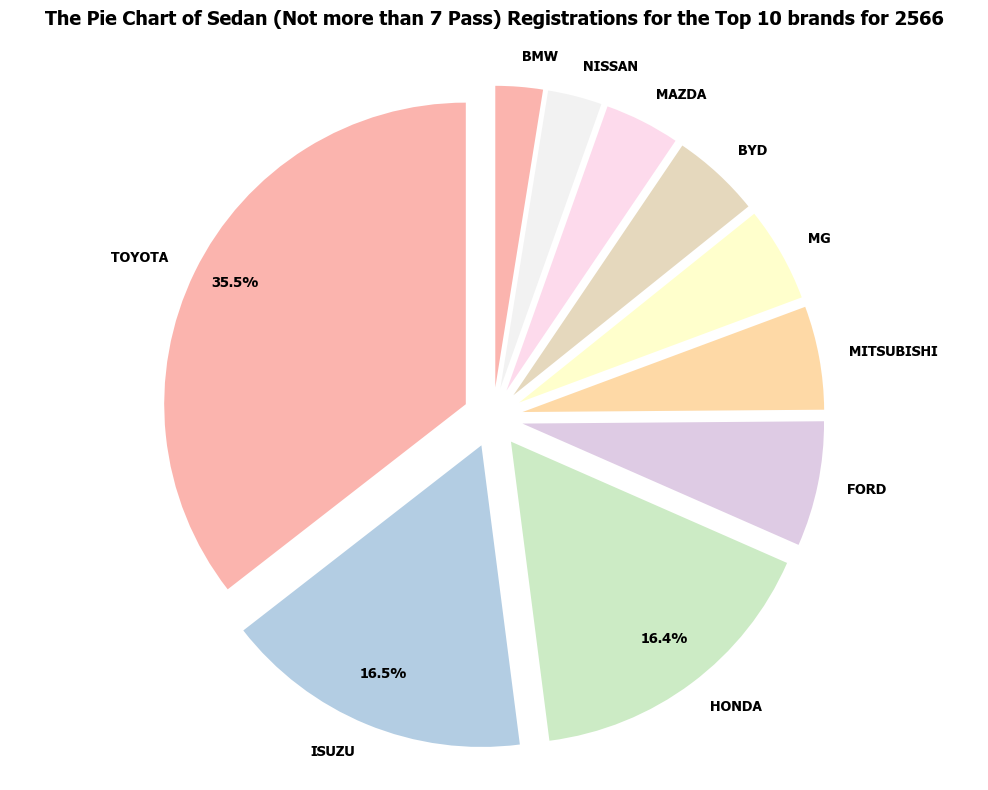


10 Brands with the Highest Number of Registrations for 2567:
        Brands    Amount
61      TOYOTA  223029.0
24       HONDA  128772.0
27       ISUZU   75090.0
20        FORD   36465.0
9          BYD   32189.0
45  MITSUBISHI   29882.0
43          MG   25405.0
8          BMW   17045.0
40       MAZDA   16163.0
48      NISSAN   14287.0


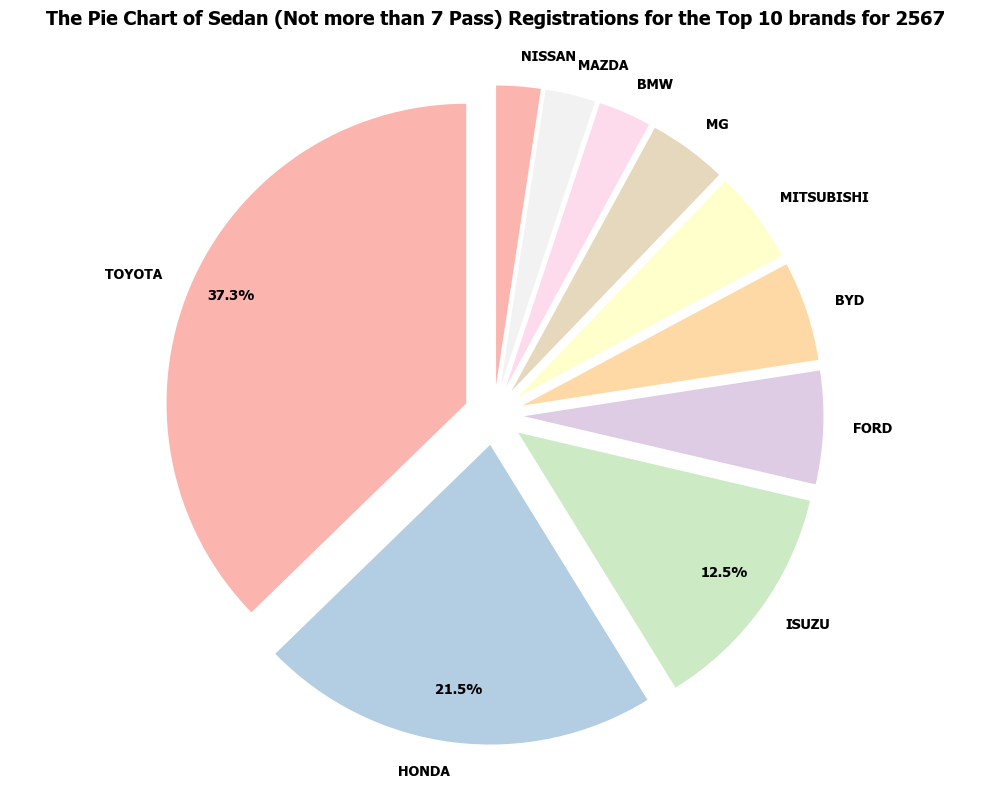

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Set Thai font support
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['TH Sarabun New', 'Tahoma', 'Arial']

# Load the raw CSV to inspect it
with open('2024-2025car.csv', 'r', encoding='utf-8') as file:
    print("Raw CSV content (first 5 lines):")
    for i, line in enumerate(file):
        if i < 5:
            print(line.strip())
        else:
            break

# Load the data with error handling
try:
    df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8')
except pd.errors.ParserError as e:
    print(f"ParserError occurred: {e}")
    df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8', on_bad_lines='skip')

# Filter for "รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน" only
df_cars = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)'].copy()  # Use .copy() to avoid view issues

# Print column names and first few rows to verify structure
print("\nColumn names:", df_cars.columns.tolist())
print("\nFirst 5 rows of filtered data:")
print(df_cars.head())

# Ensure 'จำนวน' is numeric, replacing invalid values with 0, using .loc
df_cars.loc[:, 'Amount'] = pd.to_numeric(df_cars['Amount'], errors='coerce').fillna(0)

# Filter data for each year
df_2565 = df_cars[df_cars['Year'] == 2565]
df_2566 = df_cars[df_cars['Year'] == 2566]
df_2567 = df_cars[df_cars['Year'] == 2567]

# Filter 2567 data to include only months 1-8
df_2567_partial = df_2567[df_2567['Month'].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()

# Function to create pie chart for a given year
def plot_pie_chart(df, year):
    # Group data by brand and sum the quantities
    brand_summary = df.groupby('Brands')['Amount'].sum().reset_index()

    # Sort and get top 10 brands with positive values
    top_10_brands = brand_summary[brand_summary['Amount'] > 0].nlargest(10, 'Amount')

    # Check if we have valid data
    if top_10_brands.empty:
        print(f"\nThere is no accurate data available for creating a Pie Chart for {year}") #ไม่มีข้อมูลที่ถูกต้องสำหรับการสร้างแผนภูมิสำหรับปี {year}
        print("Brand summary (all values):")
        print(brand_summary)
    else:
        print(f"\n10 Brands with the Highest Number of Registrations for {year}:") #อันดับยี่ห้อที่มีการจดทะเบียนสูงสุดสำหรับปี {year}
        print(top_10_brands)

        # Prepare data for the pie chart
        labels = top_10_brands['Brands']
        sizes = top_10_brands['Amount']
        explode = [0.1] * len(labels)

        # Create the pie chart with adjusted font sizes
        plt.figure(figsize=(10, 8))
        plt.pie(sizes,
                labels=labels,
                explode=explode,
                autopct=lambda pct: f'{pct:.1f}%\n' if pct > 10 else '',
                startangle=90,
                colors=plt.cm.Pastel1.colors,
                textprops={'fontsize': 10, 'weight': 'bold'},  # Reduced label font size
                pctdistance=0.85)  # Adjust percentage text position

        plt.title(f'The Pie Chart of Sedan (Not more than 7 Pass) Registrations for the Top 10 brands for {year}', #การกระจายของยอดจดทะเบียนรถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน 10 อันดับยี่ห้อ ปี {year}
                  fontsize=14,  # Reduced title font size
                  weight='bold',
                  pad=20)

        plt.axis('equal')
        plt.tight_layout()
        plt.show()

# Plot for 2565
plot_pie_chart(df_2565, 2565)

# Plot for 2566
plot_pie_chart(df_2566, 2566)

# Plot for 2567 (partial year)
plot_pie_chart(df_2567, 2567)


10 Best-Selling Car Model for 2565-2567:
      Brands       Car Model    Amount
605    ISUZU           D-MAX  218803.0
1719  TOYOTA      YARIS ATIV  150227.0
1583  TOYOTA      HILUX REVO  139193.0
1534  TOYOTA        FORTUNER   75667.0
499    HONDA            CITY   73726.0
516    HONDA            HR-V   73436.0
500    HONDA  CITY HATCHBACK   66924.0
1511  TOYOTA   COROLLA CROSS   66264.0
609    ISUZU            MU-X   61223.0
1718  TOYOTA           YARIS   60808.0

Projected Monthly Car Registrations for 2568 (Top 10 Best-Selling Models):
    Brands   Car Model      Month  predicted_2568
0    HONDA        CITY    January          286.18
1    HONDA        CITY   February          272.14
2    HONDA        CITY      March          276.51
3    HONDA        CITY      April          182.25
4    HONDA        CITY        May          240.17
..     ...         ...        ...             ...
7   TOYOTA  YARIS ATIV     August          602.65
8   TOYOTA  YARIS ATIV  September          602.51
9  

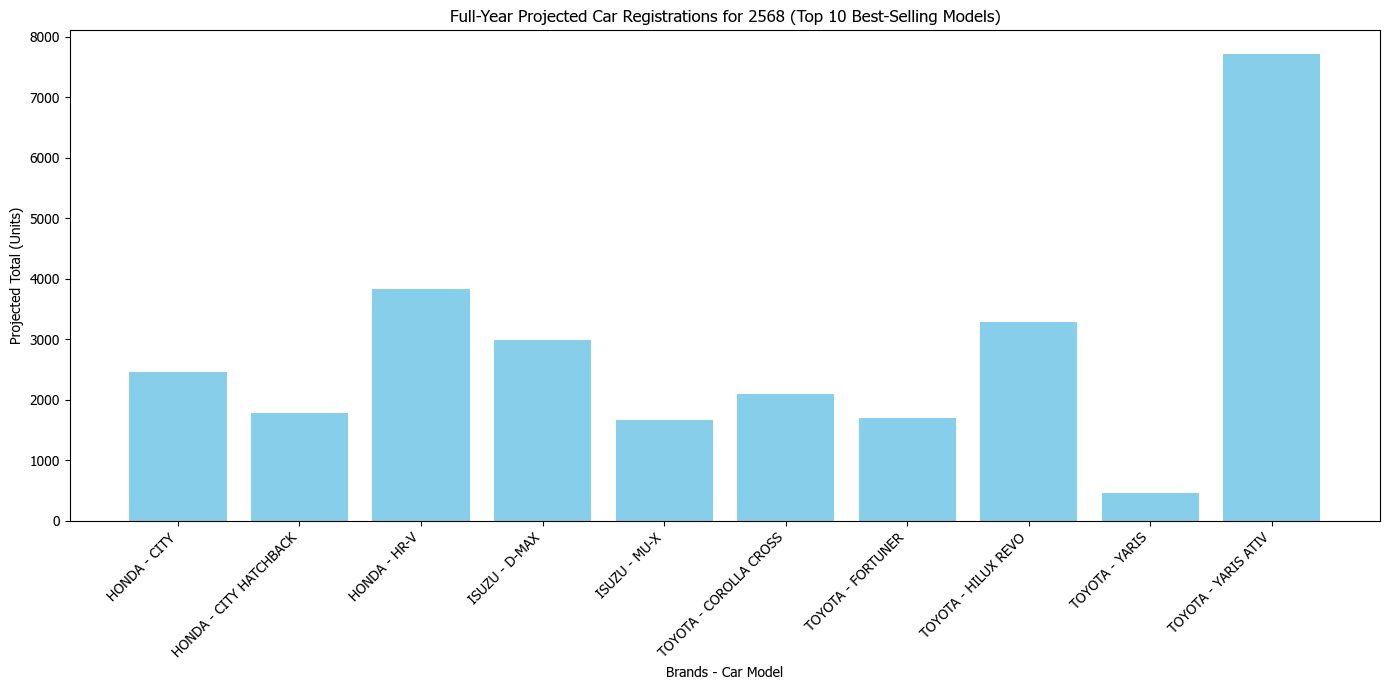

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Set Thai font support
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['TH Sarabun New', 'Tahoma', 'Arial']

# Load data
df = pd.read_csv('2024-2025car.csv', delimiter=',', encoding='utf-8', on_bad_lines='skip')

# Filter for "รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน" and ensure 'จำนวน' is numeric
df_cars = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)'].copy()
df_cars['Amount'] = pd.to_numeric(df_cars['Amount'], errors='coerce').fillna(0)

# Filter data for 2565, 2566, and 2567
df_2565 = df_cars[df_cars['Year'] == 2565]
df_2566 = df_cars[df_cars['Year'] == 2566]
df_2567 = df_cars[df_cars['Year'] == 2567]

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Summarize by brand, model, and month
brand_model_month_2565 = df_2565.groupby(['Brands', 'Car Model', 'Month'])['Amount'].sum().reset_index()
brand_model_month_2566 = df_2566.groupby(['Brands', 'Car Model', 'Month'])['Amount'].sum().reset_index()
brand_model_month_2567 = df_2567.groupby(['Brands', 'Car Model', 'Month'])['Amount'].sum().reset_index()

# Merge data for all years (2565, 2566, 2567)
brand_model_month = pd.concat([brand_model_month_2565.assign(year=2565), 
                               brand_model_month_2566.assign(year=2566), 
                               brand_model_month_2567.assign(year=2567)])

# Get top 10 models by total registrations across 2565-2567
total_by_model = brand_model_month.groupby(['Brands', 'Car Model'])['Amount'].sum().reset_index()
top_10_models = total_by_model.nlargest(10, 'Amount')[['Brands', 'Car Model']]

# Filter data to include only the top 10 models
brand_model_month = brand_model_month.merge(top_10_models, on=['Brands', 'Car Model'], how='inner')

# Prepare data for regression and prediction
predictions_2568 = []
for _, row in top_10_models.iterrows():
    brand = row['Brands']
    model = row['Car Model']
    brand_model_data = brand_model_month[
        (brand_model_month['Brands'] == brand) & 
        (brand_model_month['Car Model'] == model)
    ]
    
    # X: year, y: จำนวน
    X = brand_model_data[['year']].values
    y = brand_model_data['Amount'].values
    
    # Train Linear Regression model
    model_lr = LinearRegression()
    model_lr.fit(X, y)
    
    # Predict total for 2568
    predicted_2568_total = model_lr.predict(np.array([[2568]]))[0]
    
    # Ensure all months from 2566 are included for distribution
    brand_model_2566 = brand_model_month_2566[
        (brand_model_month_2566['Brands'] == brand) & 
        (brand_model_month_2566['Car Model'] == model)
    ].copy()
    all_months = pd.DataFrame({'Month': month_order})
    brand_model_2566 = all_months.merge(brand_model_2566, on='Month', how='left').fillna({'Amount': 0, 'Brands': brand, 'Car Model': model})
    
    # Distribute total prediction across months based on 2566 proportions
    total_2566 = brand_model_2566['Amount'].sum()
    if total_2566 == 0:  # Avoid division by zero
        brand_model_2566['predicted_2568'] = predicted_2568_total / 12
    else:
        brand_model_2566['predicted_2568'] = (brand_model_2566['Amount'] / total_2566) * predicted_2568_total
    predictions_2568.append(brand_model_2566)

# Combine predictions
brand_model_trend = pd.concat(predictions_2568)
brand_model_trend['Month'] = pd.Categorical(brand_model_trend['Month'], categories=month_order, ordered=True)
brand_model_trend = brand_model_trend.sort_values(['Brands', 'Car Model', 'Month'])

# Calculate total predicted registrations per brand and model for 2568
total_by_brand_model = brand_model_trend.groupby(['Brands', 'Car Model'])['predicted_2568'].sum().reset_index()
total_by_brand_model.columns = ['Brands', 'Car Model', 'Projected Total_2568'] #Projected Total = ยอดรวมคาดการณ์

# Print top 10 models from 2565-2567
print("\n10 Best-Selling Car Model for 2565-2567:") #รุ่นที่ขายดีที่สุดจากข้อมูลรวม 2565-2567
print(total_by_model.nlargest(10, 'Amount').round(2))

# Print results with monthly predictions
print("\nProjected Monthly Car Registrations for 2568 (Top 10 Best-Selling Models):") #คาดการณ์ยอดจดทะเบียนรถยนต์รายเดือน ปี 2568 (10 รุ่นที่ขายดีที่สุด)
print(brand_model_trend[['Brands', 'Car Model', 'Month', 'predicted_2568']].round(2))

# Print total predictions per brand and model
print("\nProjected Annual Total for 2568 (Top 10 Best-Selling Models):") #ยอดรวมคาดการณ์ทั้งปี 2568 สำหรับ 10 รุ่นที่ขายดีที่สุด
print(total_by_brand_model.round(2))

# Plot Bar Chart for Total Predicted Registrations in 2568
plt.figure(figsize=(14, 7))
models_labels = [f"{row['Brands']} - {row['Car Model']}" for _, row in total_by_brand_model.iterrows()]
plt.bar(models_labels, total_by_brand_model['Projected Total_2568'], color='skyblue') #Projected Total = ยอดรวมคาดการณ์
plt.xlabel('Brands - Car Model')
plt.ylabel('Projected Total (Units)') #ยอดรวมคาดการณ์ (คัน)
plt.title('Full-Year Projected Car Registrations for 2568 (Top 10 Best-Selling Models)') #ยอดจดทะเบียนรถยนต์คาดการณ์ทั้งปี 2568 (10 รุ่นที่ขายดีที่สุด)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Dataset loaded successfully:
   Year     Month                 Types of Cars Brands  \
0  2565  December  Sedan (Not more than 7 Pass)   AUDI   
1  2565  December  Sedan (Not more than 7 Pass)   AUDI   
2  2565  December  Sedan (Not more than 7 Pass)   AUDI   
3  2565  December  Sedan (Not more than 7 Pass)   AUDI   
4  2565  December  Sedan (Not more than 7 Pass)   AUDI   

                   Car Model  Amount  
0       A1 SB 35 TFSI S line     2.0  
1  A4 AV 45 TFSI q S line BE     2.0  
2       A5 CP 40 TFSI S line    10.0  
3  A5 CP 45 TFSI q S line BE     4.0  
4       A5 SB 40 TFSI S line    10.0  

Total Sales by Year and Brand (Units):
Brands      BYD  DEEPAL     NETA     ORA   TESLA
Year                                            
2565      404.0     0.0     71.0  3828.0   422.0
2566    26790.0     0.0  11428.0  6045.0  7212.0
2567    32318.0  4149.0   8872.0  3401.0  5974.0

Year-over-Year Growth Rates (%):
                     BYD  DEEPAL      NETA    ORA    TESLA
2566 Growt

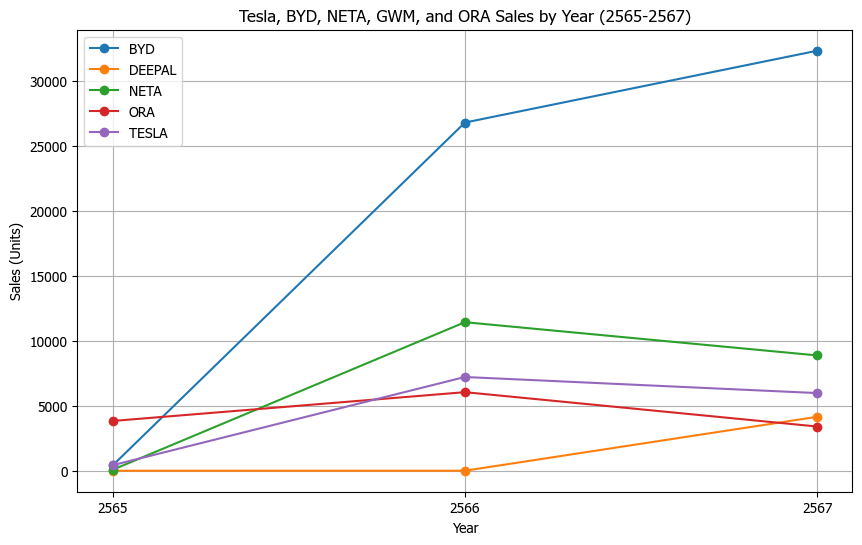

In [35]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset from '2024-2025car.csv'
try:
    df = pd.read_csv('2024-2025car.csv')
    print("Dataset loaded successfully:")
    print(df.head())
except FileNotFoundError:
    print("Error: '2024-2025car.csv' not found. Please ensure the file is in the correct directory or provide the full path.")
    raise
except pd.errors.ParserError:
    print("Error: Could not parse the CSV file. Please check the file format and column structure.")
    raise

# Step 2: Verify column names and clean them if needed
expected_columns = ['Year', 'Month', 'Types of Cars', 'Brands', 'Car Model', 'Amount']
if not all(col in df.columns for col in expected_columns):
    print("Warning: Expected columns not found. Available columns:", df.columns)
    print("Please ensure the CSV has columns: Year, Month, Types of Cars, Brands, Car Model, Amount")
    raise ValueError("Incorrect column names in the dataset.")

# Clean data: Remove any leading/trailing whitespace in column names and 'Brands'
df.columns = df.columns.str.strip()
df['Brands'] = df['Brands'].str.strip().str.upper()

# Step 3: Filter for TESLA, BYD, NETA, GWM, ORA
df_filtered = df[df['Brands'].isin(['TESLA', 'BYD', 'NETA', 'DEEPAL', 'ORA'])]

# Step 4: Aggregate sales (Amount) by Year and Brand
sales_by_year = df_filtered.groupby(['Year', 'Brands'])['Amount'].sum().unstack().fillna(0)

# Ensure all relevant years (2565, 2566, 2567) are present
for year in [2565, 2566, 2567]:
    if year not in sales_by_year.index:
        sales_by_year.loc[year] = 0

# Sort index to ensure correct order
sales_by_year = sales_by_year.sort_index()

# Step 5: Calculate YoY growth rates
growth_rates = pd.DataFrame()

for brand in sales_by_year.columns:
    sales_2565 = sales_by_year.loc[2565, brand] if 2565 in sales_by_year.index else 0
    sales_2566 = sales_by_year.loc[2566, brand] if 2566 in sales_by_year.index else 0
    growth_2566 = ((sales_2566 - sales_2565) / sales_2565 * 100) if sales_2565 != 0 else float('inf')
    
    sales_2567 = sales_by_year.loc[2567, brand] if 2567 in sales_by_year.index else 0
    growth_2567 = ((sales_2567 - sales_2566) / sales_2566 * 100) if sales_2566 != 0 else float('inf')
    
    growth_rates.loc['2566 Growth (%)', brand] = growth_2566
    growth_rates.loc['2567 Growth (%)', brand] = growth_2567

# Step 6: Display results
print("\nTotal Sales by Year and Brand (Units):")
print(sales_by_year)
print("\nYear-over-Year Growth Rates (%):")
print(growth_rates.round(2))

# Step 7: Visualize the sales trends
plt.figure(figsize=(10, 6))
for brand in sales_by_year.columns:
    plt.plot(sales_by_year.index, sales_by_year[brand], marker='o', label=brand)
plt.title('Tesla, BYD, NETA, GWM, and ORA Sales by Year (2565-2567)')
plt.xlabel('Year')
plt.ylabel('Sales (Units)')
plt.legend()
plt.grid(True)
plt.xticks([2565, 2566, 2567])
plt.savefig('sales_trends.png')
plt.show()

In [36]:
!pip install statsmodels

In [37]:
total_sales_by_year = sales_by_year.sum(axis=1)

# Display total EV sales
print("\nTotal EV Car Sales by Year (Units):")
for year in total_sales_by_year.index:
    print(f"Year {int(year)}: {int(total_sales_by_year[year])} units")


Total EV Car Sales by Year (Units):
Year 2565: 4725 units
Year 2566: 51475 units
Year 2567: 54714 units


In [38]:
# Import necessary libraries
import pandas as pd

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
years_of_interest = [2565, 2566, 2567]
df = df[df['Year'].isin(years_of_interest)]

# Filter for Sedan (Not more than 7 Pass)
df_sedan = df[df['Types of Cars'] == 'Sedan (Not more than 7 Pass)']

# Filter for the brands of interest
brands_of_interest = ['TESLA', 'BYD', 'NETA', 'DEEPAL', 'ORA']
df_brands = df_sedan[df_sedan['Brands'].isin(brands_of_interest)]

# Calculate total registrations for Sedan (Not more than 7 Pass) by year
total_registrations = df_sedan.groupby('Year')['Amount'].sum()

# Calculate registrations for the brands of interest by year
brand_registrations = df_brands.groupby('Year')['Amount'].sum()

# Calculate market share (%)
market_share = (brand_registrations / total_registrations * 100).fillna(0)

# Create a DataFrame for market share results
market_share_df = pd.DataFrame({
    'Total Registrations': total_registrations,
    ' TESLA, BYD, NETA, DEEPAL, ORA': brand_registrations,
    'Market Share (%)': market_share
}).fillna(0)

# Display the market share results
print("\nMarket Share for TESLA, BYD, NETA, DEEPAL, ORA in Sedan (Not more than 7 Pass):")
print(market_share_df)


Market Share for TESLA, BYD, NETA, DEEPAL, ORA in Sedan (Not more than 7 Pass):
      Total Registrations   TESLA, BYD, NETA, DEEPAL, ORA  Market Share (%)
Year                                                                       
2565             610130.0                          4692.0          0.769016
2566             631925.0                         51342.0          8.124698
2567             672110.0                         54581.0          8.120843
